### Домашняя работа №5 — Depth Anything 3

**Статья:** Lin et al., *Depth Anything 3: Recovering the Visual Space from Any
Views*, 2025 (arXiv: 2511.10647; код: github.com/ByteDance-Seed/Depth-Anything-3;
ICLR 2026).

In [ ]:
!pip install -q xformers
!git clone -q https://github.com/ByteDance-Seed/Depth-Anything-3.git
%cd Depth-Anything-3
!pip install -q -e .
%cd ..
import sys; sys.path.insert(0, "/content/Depth-Anything-3")

!pip install -q -U transformers

import torch, numpy as np, glob, os
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

fatal: destination path 'Depth-Anything-3' already exists and is not an empty directory.
/content/Depth-Anything-3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for depth-anything-3 (pyproject.toml) ... done
/content
device: cuda


In [ ]:
os.makedirs("imgs", exist_ok=True)
exts = ("*.png", "*.jpg", "*.jpeg")
found = []
for root, _, _ in os.walk("Depth-Anything-3/assets/examples"):
    for e in exts:
        found += glob.glob(os.path.join(root, e))
found = sorted(found)[:4]

if not found:
    from skimage import data
    from PIL import Image
    for name in ["astronaut", "chelsea", "coffee", "rocket"]:
        img = getattr(data, name)()
        p = f"imgs/{name}.png"; Image.fromarray(img).save(p); found.append(p)

IMG_PATHS = found[:4]
print("изображения:", IMG_PATHS)

изображения: ['Depth-Anything-3/assets/examples/SOH/000.png', 'Depth-Anything-3/assets/examples/SOH/010.png']


In [ ]:
import sys
sys.path.insert(0, "/content/Depth-Anything-3")
from depth_anything_3.api import DepthAnything3


MODEL_ID = "depth-anything/DA3-SMALL"
model = DepthAnything3.from_pretrained(MODEL_ID).to(device=DEVICE)

preds = [model.inference([p]) for p in IMG_PATHS]
rgb   = [pr.processed_images[0] for pr in preds]
depth = [pr.depth[0] for pr in preds]
conf  = [pr.conf[0] for pr in preds]
K     = [pr.intrinsics[0] for pr in preds]
print("depth shapes:", [d.shape for d in depth])
print("пример intrinsics (fx,fy,cx,cy):",
      K[0][0, 0], K[0][1, 1], K[0][0, 2], K[0][1, 2])

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(



config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

[INFO ] using MLP layer as FFN


model.safetensors:   0%|          | 0.00/137M [00:00<?, ?B/s]

[INFO ] Processed Images Done taking 0.13664531707763672 seconds. Shape:  torch.Size([1, 3, 280, 504])
[INFO ] Model Forward Pass Done. Time: 1.5008306503295898 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0016455650329589844 seconds
[INFO ] Processed Images Done taking 0.033661603927612305 seconds. Shape:  torch.Size([1, 3, 280, 504])
[INFO ] Model Forward Pass Done. Time: 0.2769341468811035 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0012018680572509766 seconds
depth shapes: [(280, 504), (280, 504)]
пример intrinsics (fx,fy,cx,cy): 409.925 408.51593 252.0 140.0


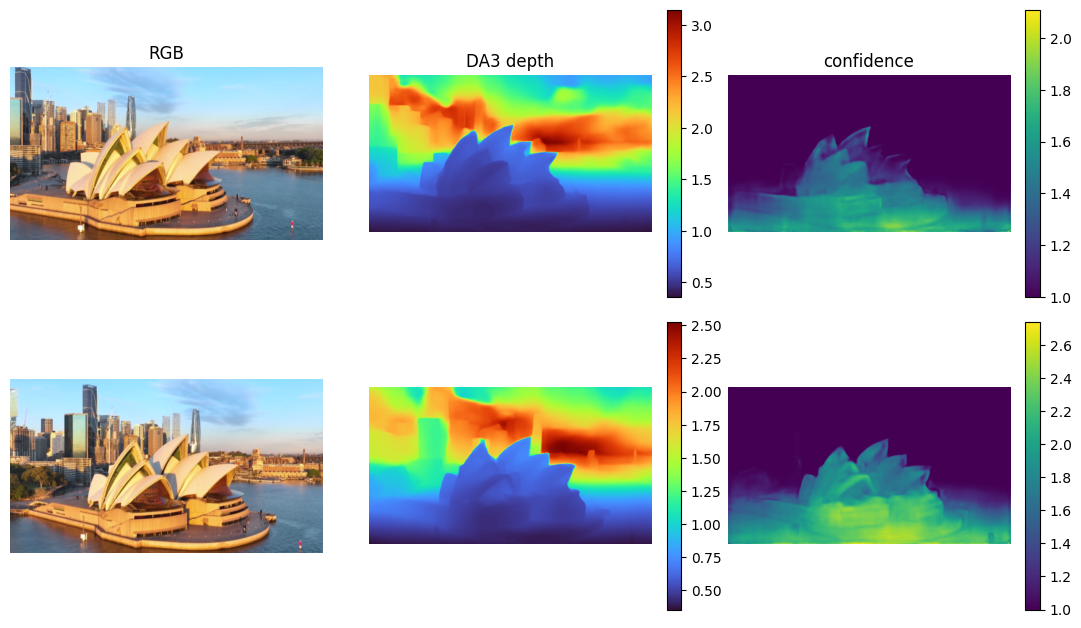

In [ ]:
import matplotlib.pyplot as plt

n = len(IMG_PATHS)
fig, ax = plt.subplots(n, 3, figsize=(11, 3.2 * n))
ax = np.atleast_2d(ax)
for i in range(n):
    ax[i, 0].imshow(rgb[i]);                       ax[i, 0].set_title("RGB" if i == 0 else "")
    im1 = ax[i, 1].imshow(depth[i], cmap="turbo"); ax[i, 1].set_title("DA3 depth" if i == 0 else "")
    im2 = ax[i, 2].imshow(conf[i], cmap="viridis");ax[i, 2].set_title("confidence" if i == 0 else "")
    plt.colorbar(im1, ax=ax[i, 1], fraction=0.046)
    plt.colorbar(im2, ax=ax[i, 2], fraction=0.046)
    for a in ax[i]:
        a.axis("off")
plt.tight_layout(); plt.savefig("da3_depth.png", dpi=150); plt.show()

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

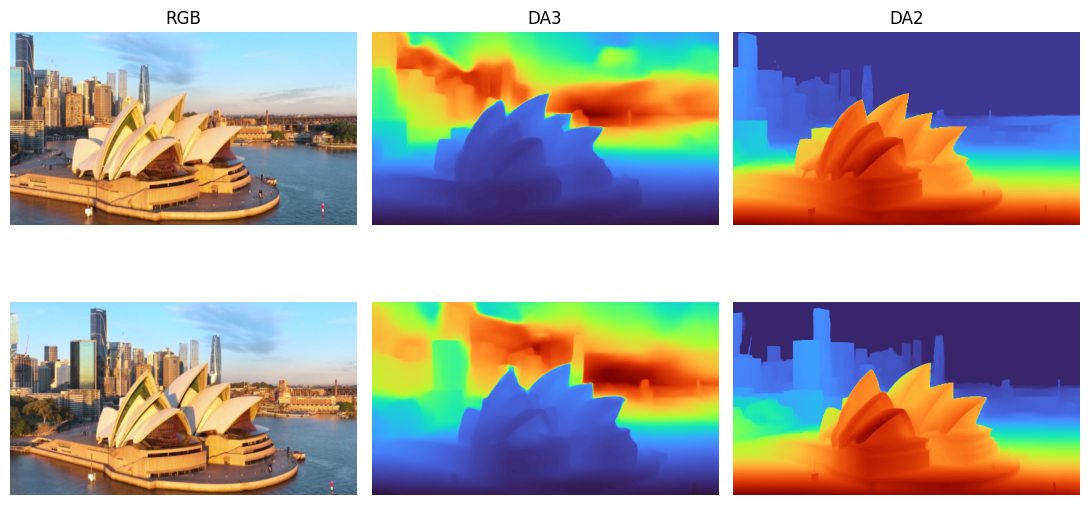

,DA3 sharpness,DA2 sharpness,"Spearman ρ(DA3,DA2)"
image,,,
000.png,28.9,151.2,-0.855
010.png,29.7,122.0,-0.885


In [ ]:
from transformers import pipeline
from PIL import Image
import cv2

da2 = pipeline(task="depth-estimation",
               model="depth-anything/Depth-Anything-V2-Small-hf",
               device=0 if DEVICE == "cuda" else -1)

def sharpness(d):
    dn = (d - d.min()) / (d.ptp() + 1e-9)
    return cv2.Laplacian((dn * 255).astype(np.uint8), cv2.CV_64F).var()

from scipy.stats import spearmanr
rows = []
fig, ax = plt.subplots(n, 3, figsize=(11, 3.2 * n)); ax = np.atleast_2d(ax)
for i, p in enumerate(IMG_PATHS):
    d2 = np.array(da2(Image.open(p).convert("RGB"))["depth"], dtype=np.float32)
    d3 = depth[i]
    d2r = cv2.resize(d2, (d3.shape[1], d3.shape[0]))
    rho = spearmanr(d3.ravel(), d2r.ravel()).correlation
    rows.append({"image": os.path.basename(p),
                 "DA3 sharpness": round(sharpness(d3), 1),
                 "DA2 sharpness": round(sharpness(d2r), 1),
                 "Spearman ρ(DA3,DA2)": round(rho, 3)})
    ax[i, 0].imshow(rgb[i]);                        ax[i, 0].set_title("RGB" if i == 0 else ""); ax[i,0].axis("off")
    ax[i, 1].imshow(d3, cmap="turbo");              ax[i, 1].set_title("DA3" if i == 0 else "");  ax[i,1].axis("off")
    ax[i, 2].imshow(d2r, cmap="turbo");             ax[i, 2].set_title("DA2" if i == 0 else "");  ax[i,2].axis("off")
plt.tight_layout(); plt.savefig("da3_vs_da2.png", dpi=150); plt.show()

import pandas as pd
cmp = pd.DataFrame(rows).set_index("image")
cmp.to_csv("da3_vs_da2.csv")
cmp

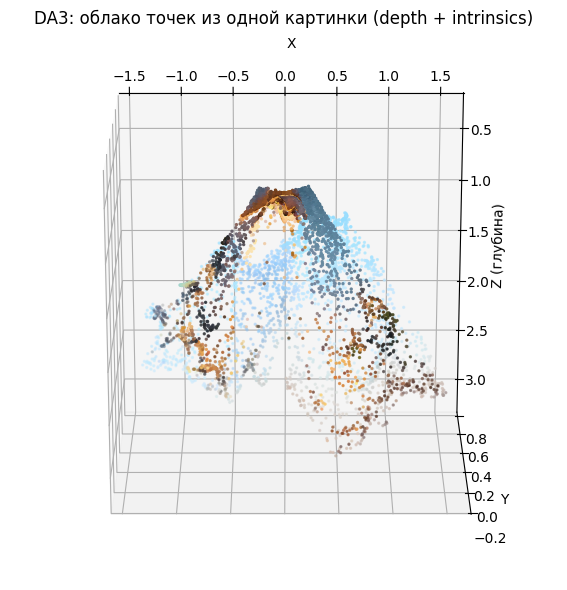

In [ ]:
idx = 0
d, im, k = depth[idx], rgb[idx], K[idx]
H, W = d.shape
fx, fy, cx, cy = k[0, 0], k[1, 1], k[0, 2], k[1, 2]
us, vs = np.meshgrid(np.arange(W), np.arange(H))
Z = d
X = (us - cx) / fx * Z
Y = (vs - cy) / fy * Z
pts = np.stack([X, Y, Z], -1).reshape(-1, 3)
cols = (im.reshape(-1, 3) / 255.0)
sel = np.random.RandomState(0).choice(len(pts), min(6000, len(pts)), replace=False)

fig = plt.figure(figsize=(7, 6)); a = fig.add_subplot(111, projection="3d")
a.scatter(pts[sel, 0], pts[sel, 2], -pts[sel, 1], c=cols[sel], s=2)
a.set_xlabel("X"); a.set_ylabel("Z (глубина)"); a.set_zlabel("Y")
a.set_title("DA3: облако точек из одной картинки (depth + intrinsics)")
a.view_init(elev=-70, azim=-90)
plt.tight_layout(); plt.savefig("da3_pointcloud.png", dpi=150); plt.show()

### Вывод

Depth Anything 3 строит детализированные карты глубины монокулярно одной плоской
трансформер-архитектурой без задачно-специфичных модулей. Сравнение с
Depth-Anything-V2 (таблица выше): обе модели согласованы по структуре сцены
(высокая ранговая корреляция Спирмена — абсолютные масштабы разные, поэтому
сравниваем ранги), но отличаются по детализации краёв (дисперсия лапласиана).

Главное качественное отличие DA3 — единое **depth-ray** представление: модель
выдаёт не только глубину, но и параметры камеры, поэтому из одной картинки можно
поднять метрически согласованное **облако 3D-точек** (последний график) — DA2,
у которого нет камеры, так не умеет. Именно эта геометрическая согласованность —
причина, по которой DA3 обходит DA2 в монокуляре и VGGT в многовидовой
реконструкции/оценке позы (см. статью).

Ограничения демонстрации: без ground-truth глубины сравнение качественное
(резкость + ранговая корреляция), а не по абсолютной ошибке. Для усиления:
датасет с GT-глубиной (NYU/KITTI) и метрики AbsRel/δ1, а также многовидовой
режим DA3 (несколько кадров одной сцены → согласованная реконструкция и поза),
где преимущество DA3 над монокулярными методами максимально.